# Tesla ML pipeline


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

## 1. Load Data & EDA

In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.shape, df.dtypes

((2640, 12),
 Year                      int64
 Month                     int64
 Region                   object
 Model                    object
 Estimated_Deliveries      int64
 Production_Units          int64
 Avg_Price_USD           float64
 Battery_Capacity_kWh      int64
 Range_km                  int64
 CO2_Saved_tons          float64
 Source_Type              object
 Charging_Stations         int64
 dtype: object)

In [4]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

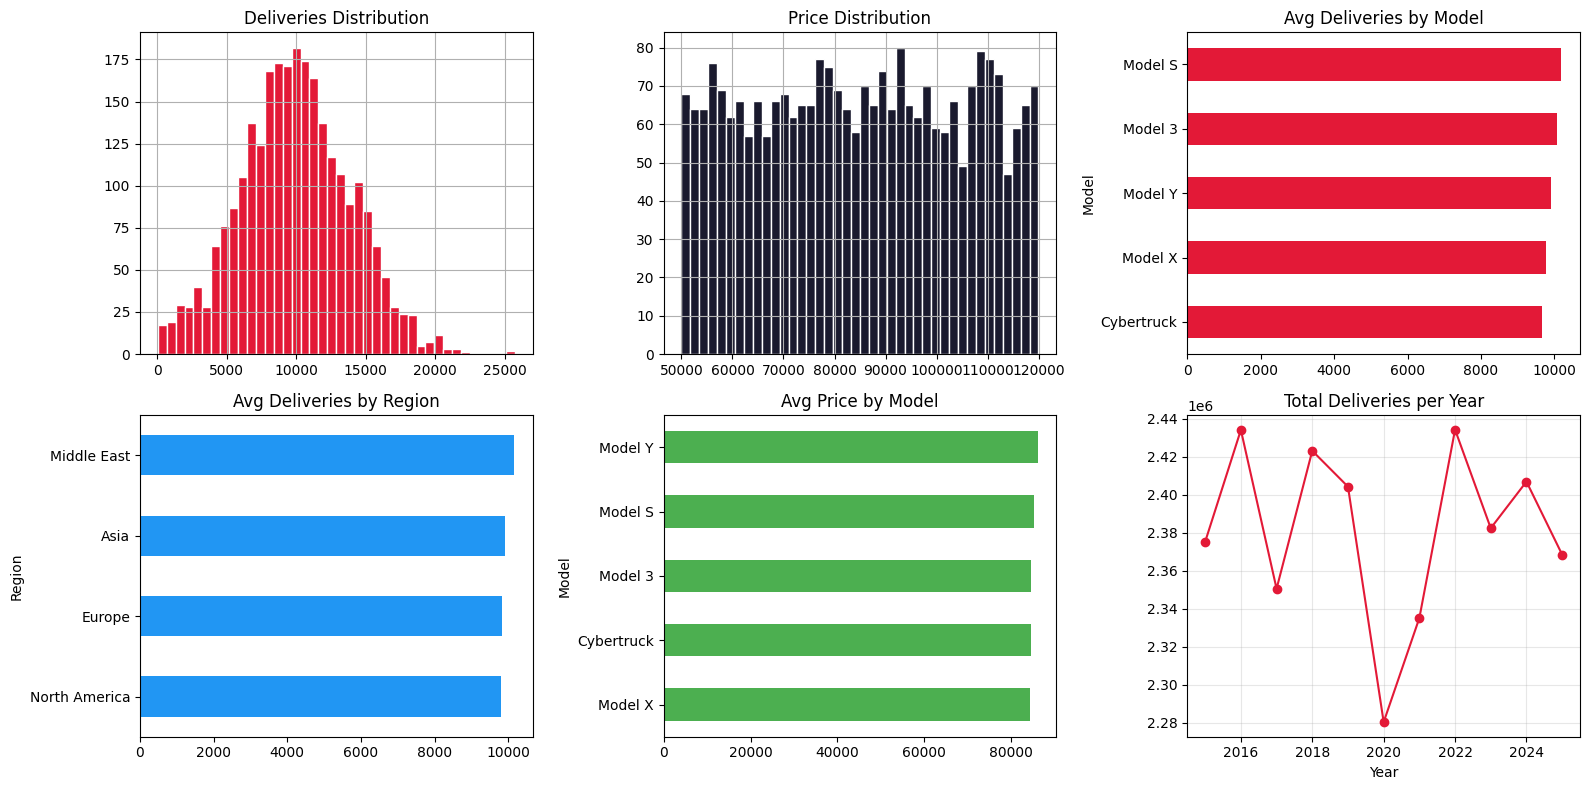

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
df['Estimated_Deliveries'].hist(ax=axes[0,0], bins=40, color='#e31937', edgecolor='white')
axes[0,0].set_title('Deliveries Distribution')

df['Avg_Price_USD'].hist(ax=axes[0,1], bins=40, color='#1a1a2e', edgecolor='white')
axes[0,1].set_title('Price Distribution')

df.groupby('Model')['Estimated_Deliveries'].mean().sort_values().plot(kind='barh', ax=axes[0,2], color='#e31937')
axes[0,2].set_title('Avg Deliveries by Model')

df.groupby('Region')['Estimated_Deliveries'].mean().sort_values().plot(kind='barh', ax=axes[1,0], color='#2196F3')
axes[1,0].set_title('Avg Deliveries by Region')

df.groupby('Model')['Avg_Price_USD'].mean().sort_values().plot(kind='barh', ax=axes[1,1], color='#4caf50')
axes[1,1].set_title('Avg Price by Model')

df.groupby('Year')['Estimated_Deliveries'].sum().plot(marker='o', ax=axes[1,2], color='#e31937')
axes[1,2].set_title('Total Deliveries per Year')
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

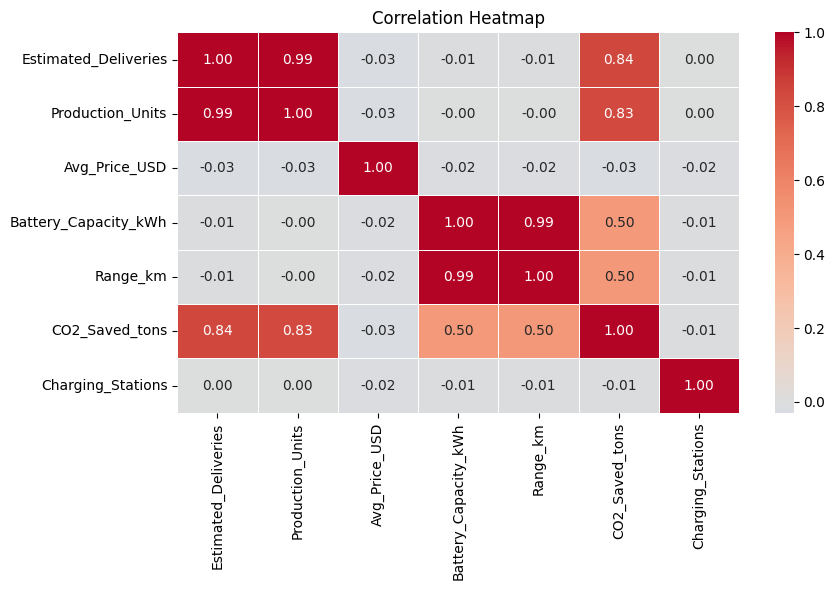

In [7]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
            'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [8]:
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))
df = df.sort_values(['Model','Region','Date']).reset_index(drop=True)

df['Quarter']          = df['Month'].apply(lambda m: (m-1)//3 + 1)
df['Month_sin']        = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']        = np.cos(2 * np.pi * df['Month'] / 12)
df['Years_Since_2015'] = df['Year'] - 2015
df['Range_per_kWh']    = df['Range_km'] / df['Battery_Capacity_kWh']
df['CO2_per_Delivery'] = df['CO2_Saved_tons'] / df['Estimated_Deliveries'].clip(lower=1)
df['Efficiency']       = df['Estimated_Deliveries'] / df['Production_Units'].clip(lower=1)

grp = df.groupby(['Model','Region'])
df['Lag1_Price']       = grp['Avg_Price_USD'].shift(1)
df['Lag3_Price']       = grp['Avg_Price_USD'].shift(3)
df['Lag1_Delivery']    = grp['Estimated_Deliveries'].shift(1)
df['Roll3_Del']        = grp['Estimated_Deliveries'].transform(lambda x: x.shift(1).rolling(3).mean())
df['MoM_Delivery_pct'] = grp['Estimated_Deliveries'].pct_change()

df = df.dropna().reset_index(drop=True)
df.shape

(2580, 25)

In [9]:
le_region = LabelEncoder(); le_model = LabelEncoder(); le_src = LabelEncoder()
df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Source_enc'] = le_src.fit_transform(df['Source_Type'])

FEATURES = ['Model_enc','Region_enc','Years_Since_2015','Quarter','Month_sin','Month_cos',
            'Battery_Capacity_kWh','Range_km','Charging_Stations','Lag1_Price','Lag3_Price',
            'Lag1_Delivery','Range_per_kWh','Roll3_Del','CO2_per_Delivery','Efficiency',
            'MoM_Delivery_pct','Source_enc']
TARGET = 'Estimated_Deliveries'
print(f"Features: {len(FEATURES)}  |  Rows: {len(df)}")

Features: 18  |  Rows: 2580


## 3. Train/Test Split

In [10]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (2064, 18)  Test: (516, 18)


## 4. Baseline Model Comparison

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

model_zoo = {
    'Linear Regression': LinearRegression(),
    'Lasso':             Lasso(alpha=100, max_iter=5000),
    'Ridge':             Ridge(alpha=50),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, subsample=0.8, random_state=42),
}

results = {}
for name, mdl in model_zoo.items():
    pipe = Pipeline([('sc', StandardScaler()), ('m', mdl)])
    pipe.fit(X_train, y_train)
    yp   = pipe.predict(X_test)
    cv   = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring='r2').mean()
    results[name] = dict(pipe=pipe, y_pred=yp,
        MAE=mean_absolute_error(y_test, yp),
        RMSE=np.sqrt(mean_squared_error(y_test, yp)),
        R2=r2_score(y_test, yp), CV_R2=cv)

pd.DataFrame({n: {'R²': f"{v['R2']:.4f}", 'CV R²': f"{v['CV_R2']:.4f}",
                   'RMSE': f"{v['RMSE']:.0f}", 'MAE': f"{v['MAE']:.0f}"}
              for n, v in results.items()}).T

,R²,CV R²,RMSE,MAE
Linear Regression,0.0086,-0.7912,3850,3039
Lasso,0.0129,-0.5448,3842,3036
Ridge,0.0119,-0.5865,3844,3032
Random Forest,0.9718,0.9376,650,260
Gradient Boosting,0.9792,0.9650,558,260


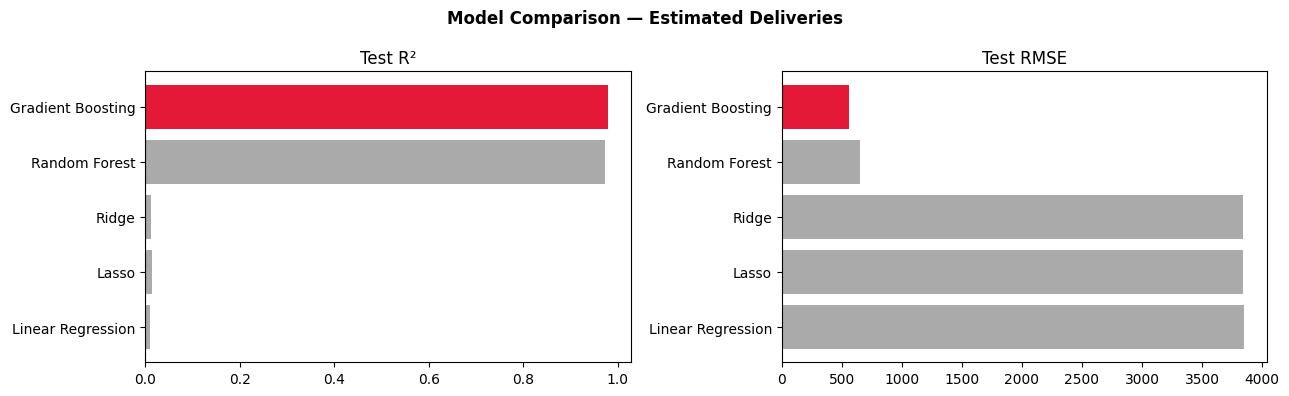

Best model: Gradient Boosting


In [12]:
names  = list(results.keys())
r2s    = [results[n]['R2']   for n in names]
rmses  = [results[n]['RMSE'] for n in names]
best   = max(results, key=lambda k: results[k]['R2'])
colors = ['#e31937' if n == best else '#aaa' for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(names, r2s, color=colors); axes[0].axvline(0, color='k', lw=0.8, ls='--')
axes[0].set_title('Test R²')
axes[1].barh(names, rmses, color=colors)
axes[1].set_title('Test RMSE')
plt.suptitle('Model Comparison — Estimated Deliveries', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Best model: {best}")

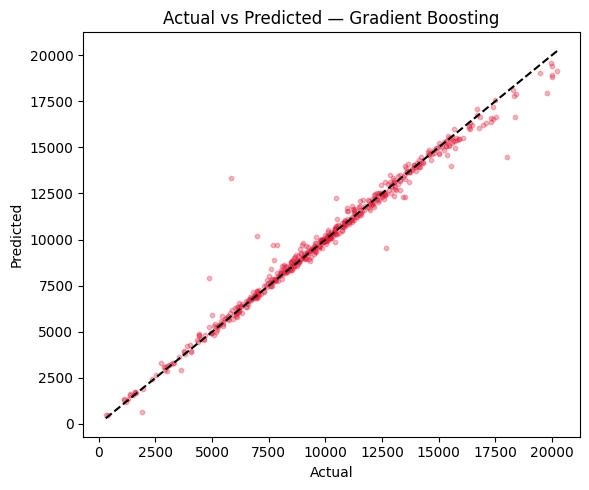

In [13]:
best_pred = results[best]['y_pred']
plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_pred, alpha=0.3, s=10, color='#e31937')
lim = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lim, lim, 'k--', lw=1.5)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted — {best}')
plt.tight_layout(); plt.show()

## 5. Hyperparameter Tuning 

In [14]:
param_grid = {
    'm__n_estimators':  [100, 200, 300],
    'm__learning_rate': [0.03, 0.05, 0.1],
    'm__max_depth':     [3, 4, 5],
    'm__subsample':     [0.7, 0.9],
}
pipe_tune = Pipeline([('sc', StandardScaler()),
                      ('m', GradientBoostingRegressor(random_state=42))])

gscv = GridSearchCV(pipe_tune, param_grid, cv=tscv, scoring='r2', n_jobs=-1, verbose=1)
gscv.fit(X_train, y_train)
print("Best params:", gscv.best_params_)
print(f"Best CV R²: {gscv.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'m__learning_rate': 0.05, 'm__max_depth': 4, 'm__n_estimators': 300, 'm__subsample': 0.7}
Best CV R²: 0.9658


In [15]:
best_tuned   = gscv.best_estimator_
y_tuned_pred = best_tuned.predict(X_test)
print(f"Test R²  : {r2_score(y_test, y_tuned_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_tuned_pred)):.0f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_tuned_pred):.0f}")

Test R²  : 0.9838
Test RMSE: 493
Test MAE : 224


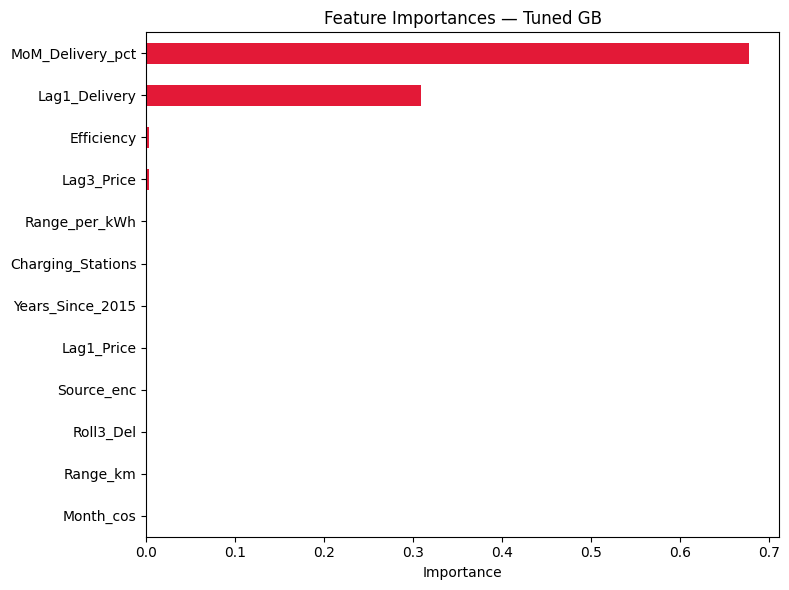

In [16]:
importances = best_tuned.named_steps['m'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values()
plt.figure(figsize=(8, 6))
feat_imp.tail(12).plot(kind='barh', color='#e31937')
plt.title('Feature Importances — Tuned GB')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## 6.Time Series Forecasting

In [17]:
del_results = {}
for mn in sorted(df['Model'].unique()):
    sub  = df[df['Model'] == mn].sort_values('Date').reset_index(drop=True)
    sp   = int(0.8 * len(sub))
    pipe = Pipeline([('sc', StandardScaler()),
                     ('gb', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                      max_depth=4, random_state=42))])
    pipe.fit(sub[FEATURES].iloc[:sp], sub[TARGET].iloc[:sp])
    yp = pipe.predict(sub[FEATURES].iloc[sp:])
    yt = sub[TARGET].iloc[sp:].values
    del_results[mn] = dict(pipe=pipe, sub=sub, split=sp,
        y_pred=yp, y_true=yt,
        dates_test=sub['Date'].iloc[sp:].values,
        dates_all=sub['Date'].values, del_all=sub[TARGET].values,
        R2=r2_score(yt, yp), RMSE=np.sqrt(mean_squared_error(yt, yp)),
        MAE=mean_absolute_error(yt, yp))

pd.DataFrame({mn: {'R²': f"{v['R2']:.4f}", 'RMSE': f"{v['RMSE']:.0f}", 'MAE': f"{v['MAE']:.0f}"}
              for mn, v in del_results.items()}).T

,R²,RMSE,MAE
Cybertruck,0.9665,648,472
Model 3,0.9736,620,408
Model S,0.8998,1094,478
Model X,0.9684,665,453
Model Y,0.9687,652,392


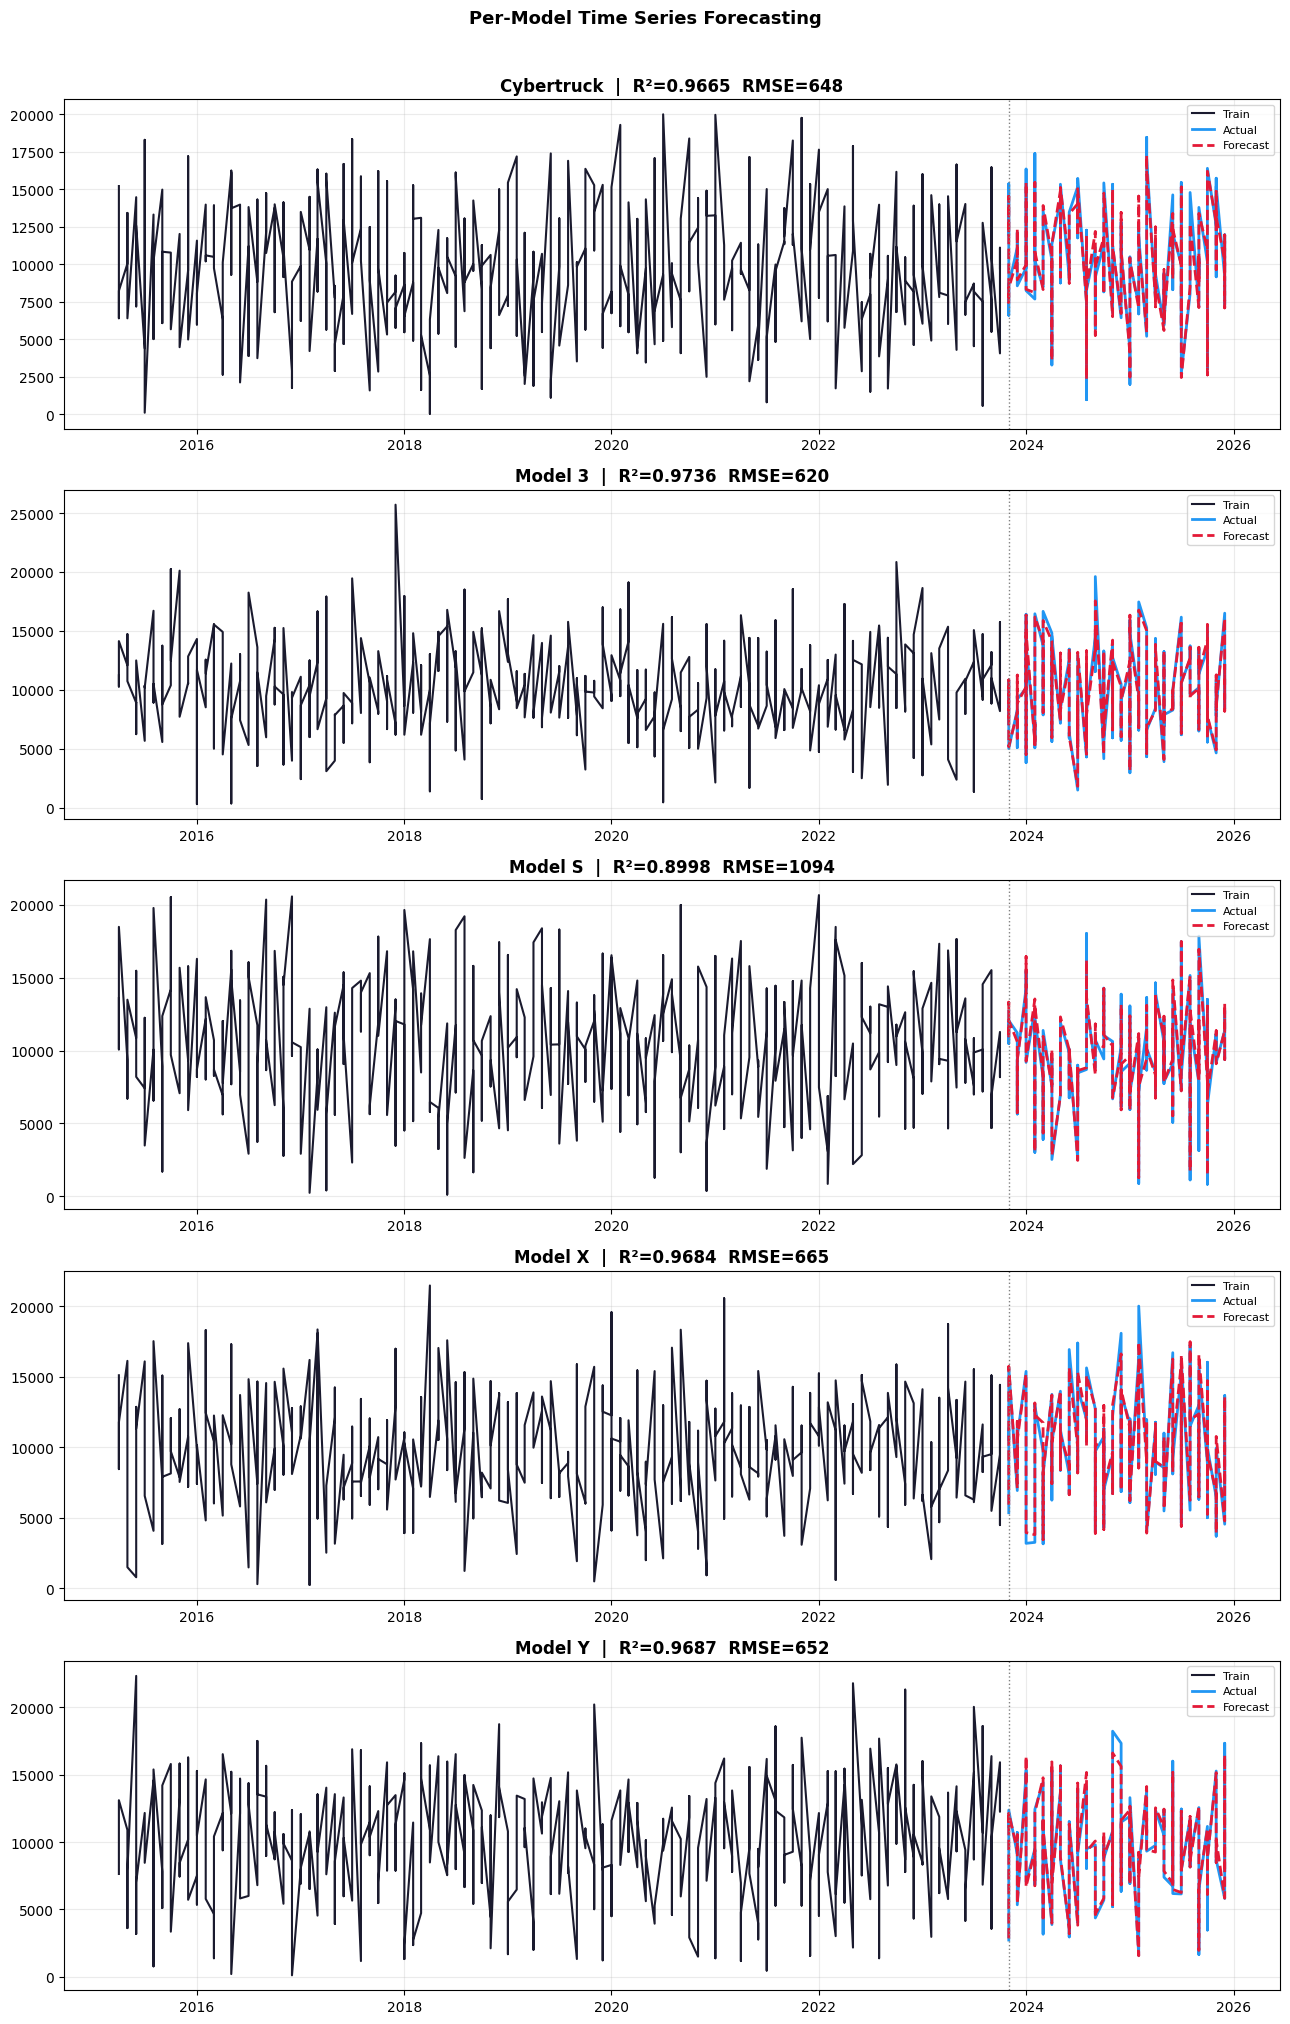

In [18]:
fig, axes = plt.subplots(len(del_results), 1, figsize=(13, 4 * len(del_results)))
for ax, (mn, res) in zip(axes, del_results.items()):
    sp = res['split']
    ax.plot(res['dates_all'][:sp], res['del_all'][:sp], color='#1a1a2e', lw=1.5, label='Train')
    ax.plot(res['dates_test'], res['y_true'], color='#2196F3', lw=2, label='Actual')
    ax.plot(res['dates_test'], res['y_pred'], color='#e31937', lw=2, ls='--', label='Forecast')
    ax.axvline(res['dates_all'][sp], color='gray', lw=1, ls=':')
    ax.set_title(f"{mn}  |  R²={res['R2']:.4f}  RMSE={res['RMSE']:.0f}", fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.suptitle('Per-Model Time Series Forecasting', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 7.Future Forecast 

In [19]:
m3_sub   = df[df['Model'] == 'Model 3'].sort_values('Date').reset_index(drop=True)
m3_pipe  = del_results['Model 3']['pipe']
last_row = m3_sub[FEATURES].iloc[-1].copy()
last_price = m3_sub['Avg_Price_USD'].iloc[-1]
last_date  = m3_sub['Date'].iloc[-1]
lag_buf    = list(m3_sub[TARGET].iloc[-3:].values)

future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=12, freq='MS')
future_preds = []

for fdate in future_dates:
    row = last_row.copy()
    row['Years_Since_2015'] = fdate.year - 2015
    row['Quarter']          = (fdate.month - 1) // 3 + 1
    row['Month_sin']        = np.sin(2 * np.pi * fdate.month / 12)
    row['Month_cos']        = np.cos(2 * np.pi * fdate.month / 12)
    row['Lag1_Delivery']    = lag_buf[-1]
    row['Roll3_Del']        = np.mean(lag_buf[-3:])
    row['Lag1_Price']       = last_price
    row['Lag3_Price']       = last_price
    row['MoM_Delivery_pct'] = (lag_buf[-1] - lag_buf[-2]) / max(lag_buf[-2], 1)
    pred = m3_pipe.predict(pd.DataFrame([row]))[0]
    future_preds.append(pred)
    lag_buf.append(pred); lag_buf.pop(0)

future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_preds})
future_df

,Date,Forecast
0,2026-01-01,12987.570664
1,2026-02-01,14221.848314
2,2026-03-01,15600.572019
3,2026-04-01,16808.186574
4,2026-05-01,17146.650955
5,2026-06-01,16110.725128
6,2026-07-01,14556.559014
7,2026-08-01,13008.596969
8,2026-09-01,11898.886579
9,2026-10-01,11124.046767


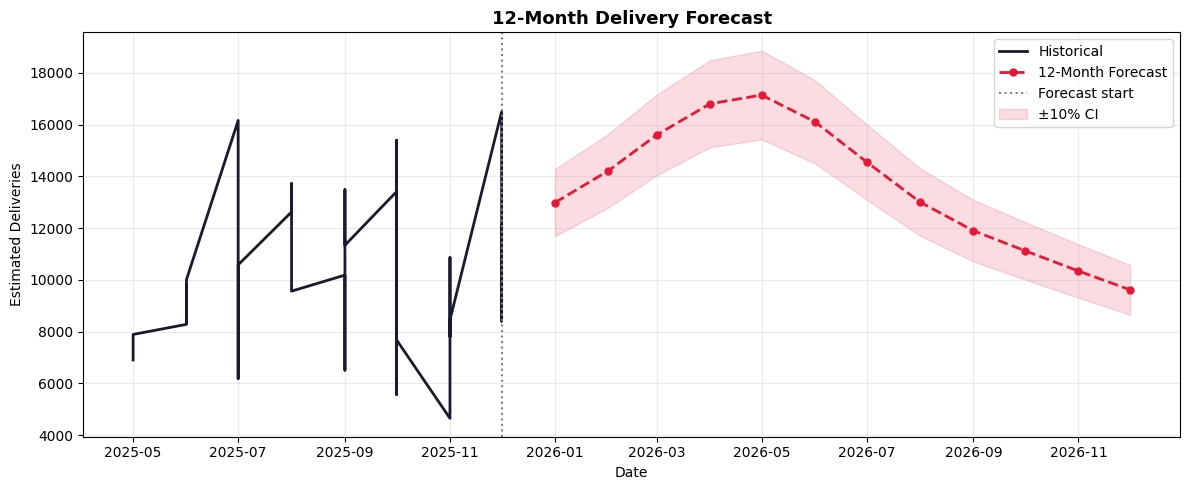

In [26]:
hist = m3_sub.tail(30)
plt.figure(figsize=(12, 5))
plt.plot(hist['Date'], hist[TARGET], color='#1a1a2e', lw=2, label='Historical')
plt.plot(future_df['Date'], future_df['Forecast'], color='#e31937', lw=2,
         marker='o', ms=5, ls='--', label='12-Month Forecast')
plt.axvline(last_date, color='gray', ls=':', lw=1.5, label='Forecast start')
plt.fill_between(future_df['Date'], future_df['Forecast'] * 0.9,
                 future_df['Forecast'] * 1.1, alpha=0.15, color='#e31937', label='±10% CI')
plt.title('12-Month Delivery Forecast', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Estimated Deliveries')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Final Results 

In [25]:
global_summary = pd.DataFrame({
    n: {'Test R²': f"{v['R2']:.4f}", 'CV R²': f"{v['CV_R2']:.4f}",
        'RMSE': f"{v['RMSE']:.0f}", 'MAE': f"{v['MAE']:.0f}"}
    for n, v in results.items()}).T

per_model_summary = pd.DataFrame({
    mn: {'R²': f"{v['R2']:.4f}", 'RMSE': f"{v['RMSE']:.0f}", 'MAE': f"{v['MAE']:.0f}"}
    for mn, v in del_results.items()}).T

print("Global Regression")
display(global_summary)
print("Per-Model Forecasting")
display(per_model_summary)

Global Regression


,Test R²,CV R²,RMSE,MAE
Linear Regression,0.0086,-0.7912,3850,3039
Lasso,0.0129,-0.5448,3842,3036
Ridge,0.0119,-0.5865,3844,3032
Random Forest,0.9718,0.9376,650,260
Gradient Boosting,0.9792,0.9650,558,260


Per-Model Forecasting


,R²,RMSE,MAE
Cybertruck,0.9665,648,472
Model 3,0.9736,620,408
Model S,0.8998,1094,478
Model X,0.9684,665,453
Model Y,0.9687,652,392
